# Лабораторная работа №2, вариант 52
## Преследование браконьерской лодки катером береговой охраны

In [7]:
using Plots

## Исходные данные

In [12]:
k = 17.4          # начальное расстояние между катером и лодкой, км
n = 4.9           # отношение скоростей (катер/лодка)
a = sqrt(n^2 - 1) # параметр спирали ≈ 4.797

4.796873982084583

## Расстояния, на которых катер переходит к спиральному движению

In [15]:
x1 = k / (n + 1)   # случай 1 (движение к полюсу)
x2 = k / (n - 1)   # случай 2 (проход через полюс)

println("x1 = $x1 км, x2 = $x2 км")

x1 = 2.949152542372881 км, x2 = 4.461538461538461 км


## Выбранные направления движения лодки

In [18]:
φ1 = π/3           # 60°
φ2 = 4π/3          # 240°

4.1887902047863905

## Точки встречи

In [21]:
r1_meet = x1 * exp(φ1 / a)
r2_meet = x2 * exp((φ2 - π) / a)

println("Точка встречи в случае 1: r = $r1_meet км, θ = $φ1 рад")
println("Точка встречи в случае 2: r = $r2_meet км, θ = $φ2 рад")

Точка встречи в случае 1: r = 3.6686589476305005 км, θ = 1.0471975511965976 рад
Точка встречи в случае 2: r = 5.550022510517937 км, θ = 4.1887902047863905 рад


# Построение траектории для случая 1
Прямолинейный участок: от начальной точки (k, 0) до (x1, 0)

In [24]:
θ_line1 = 0.0
r_line1 = range(x1, k, length=100)  # от меньшего к большему (движение к полюсу)
x_line1 = r_line1 .* cos(θ_line1)
y_line1 = r_line1 .* sin(θ_line1)

StepRangeLen(0.0, 0.0, 100)

Спиральный участок: от θ = 0 до φ1

In [27]:
θ_spiral1 = range(0, φ1, length=200)
r_spiral1 = x1 * exp.(θ_spiral1 / a)
x_spiral1 = r_spiral1 .* cos.(θ_spiral1)
y_spiral1 = r_spiral1 .* sin.(θ_spiral1)

200-element Vector{Float64}:
 0.0
 0.015536285968853026
 0.031106247386863572
 0.04670950782995635
 0.062345689084016734
 0.07801441115189967
 0.09371529226050535
 0.10944794886792196
 0.12521199567063526
 0.14100704561080496
 0.15683270988360767
 0.17268859794464675
 0.18857431751742862
 ⋮
 3.0289365739288585
 3.042707371766896
 3.0564204005095443
 3.070075136593569
 3.083671056991972
 3.0972076392303043
 3.110684361402992
 3.1241007021896805
 3.137456140871603
 3.1507501573479635
 3.1639822321523385
 3.1771518464690978

Траектория лодки: луч под углом φ1 от 0 до r1_meet

In [30]:
r_boat1 = range(0, r1_meet, length=100)
x_boat1 = r_boat1 .* cos(φ1)
y_boat1 = r_boat1 .* sin(φ1)

0.0:0.03209244289362725:3.1771518464690978

# Построение траектории для случая 2
Первый прямолинейный участок: от (k, 0) до полюса (0, 0)

In [33]:
r_line2a = range(0, k, length=100)  # от 0 до k (движение к полюсу)
x_line2a = r_line2a .* cos(0)
y_line2a = r_line2a .* sin(0)

StepRangeLen(0.0, 0.0, 100)

Второй прямолинейный участок: от полюса до (x2, π)

In [36]:
r_line2b = range(0, x2, length=100)
x_line2b = r_line2b .* cos(π)   # cos(π) = -1
y_line2b = r_line2b .* sin(π)   # sin(π) = 0

StepRangeLen(0.0, 0.0, 100)

Спиральный участок: от θ = π до φ2

In [39]:
θ_spiral2 = range(π, φ2, length=200)
r_spiral2 = x2 * exp.((θ_spiral2 .- π) / a)
x_spiral2 = r_spiral2 .* cos.(θ_spiral2)
y_spiral2 = r_spiral2 .* sin.(θ_spiral2)

200-element Vector{Float64}:
  5.463808796195883e-16
 -0.023503612106726756
 -0.04705816912371603
 -0.07066310158890858
 -0.09431783733222966
 -0.1180218014862073
 -0.14177441649666098
 -0.16557510213352294
 -0.1894232755017292
 -0.21331835105224328
 -0.2372597405931489
 -0.2612468533008756
 -0.28527909573149324
  ⋮
 -4.582237381071863
 -4.603070126519149
 -4.623815477693925
 -4.644472642538987
 -4.665040829808366
 -4.685519249091996
 -4.705907110840421
 -4.726203626389515
 -4.746408007985244
 -4.766519468808455
 -4.78653722299969
 -4.806460485684019

Траектория лодки: луч под углом φ2 от 0 до r2_meet

In [42]:
r_boat2 = range(0, r2_meet, length=100)
x_boat2 = r_boat2 .* cos(φ2)
y_boat2 = r_boat2 .* sin(φ2)

0.0:-0.048550105916000195:-4.80646048568402

# Визуализация для 1го случая

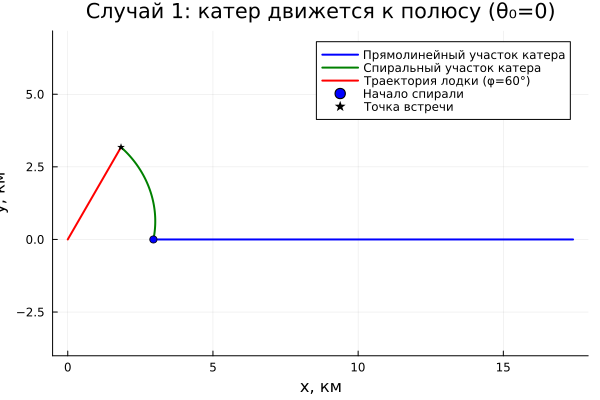

In [45]:
p1 = plot(title="Случай 1: катер движется к полюсу (θ₀=0)", aspect_ratio=:equal)
plot!(p1, x_line1, y_line1, label="Прямолинейный участок катера", color=:blue, linewidth=2)
plot!(p1, x_spiral1, y_spiral1, label="Спиральный участок катера", color=:green, linewidth=2)
plot!(p1, x_boat1, y_boat1, label="Траектория лодки (φ=60°)", color=:red, linewidth=2)
scatter!(p1, [x1], [0], label="Начало спирали", color=:blue, markershape=:circle)
scatter!(p1, [x_boat1[end]], [y_boat1[end]], label="Точка встречи", color=:black, markershape=:star)
xlabel!("x, км")
ylabel!("y, км")

# Визуализация для 2го случая

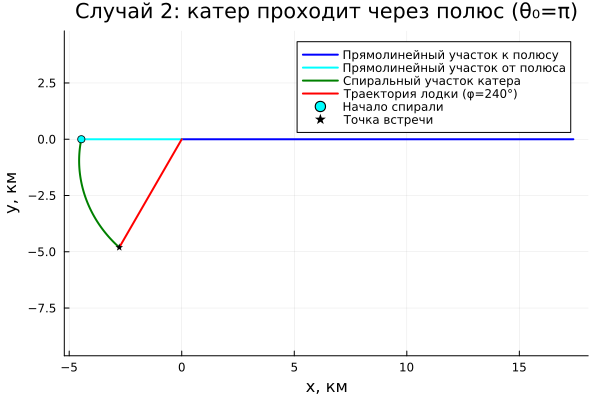

In [48]:
p2 = plot(title="Случай 2: катер проходит через полюс (θ₀=π)", aspect_ratio=:equal)
plot!(p2, x_line2a, y_line2a, label="Прямолинейный участок к полюсу", color=:blue, linewidth=2)
plot!(p2, x_line2b, y_line2b, label="Прямолинейный участок от полюса", color=:cyan, linewidth=2)
plot!(p2, x_spiral2, y_spiral2, label="Спиральный участок катера", color=:green, linewidth=2)
plot!(p2, x_boat2, y_boat2, label="Траектория лодки (φ=240°)", color=:red, linewidth=2)
scatter!(p2, [-x2], [0], label="Начало спирали", color=:cyan, markershape=:circle)
scatter!(p2, [x_boat2[end]], [y_boat2[end]], label="Точка встречи", color=:black, markershape=:star)
xlabel!("x, км")
ylabel!("y, км")

Отображение обоих графиков

In [51]:
plot(p1, p2, layout=(1,2), size=(1000,500))
savefig("trajectories.png")

"C:\\Users\\lisal\\work\\study\\2026-1\\2026-1==study--mathmod\\2026-1--study--mathmod\\labs\\lab02\\project\\notebooks\\task\\trajectories.png"